# Raster Data processing for Kitui Road water Harvesting project.
This notebook focuses on preparing rater data  for the Kitui road water harvesting suitability analysis.The raster processing workflow includes
loading raster layers,checking their coordinates reference systems,clipping them to Kitui county boundary,reprjecting them to EPSG:32737.
The raster datasets include the Digital elevation model (DEM),rainfall,landuselandcover(LULC) soil depth and other raster based criteria used in the road water harveting model.

## Purpose for Raster processing 
Raster processing is important because most suitability criteria are represented as grid based data.
In this project,raster processing prepares the data for deriving slope,reclassifying suitability classes and combining criteria using the AHP-
based weighted overlay meathod.

In [2]:
# import libraries
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
from pathlib import Path
import geopandas as gpd
print('sucess')


sucess


In [3]:
# defining paths
raw = Path('../data/raw')
processed =Path('../data/processed')

dem_path = raw / 'Kenya_SRTM30meters.tif'
kitui_boundary = processed / 'kitui_boundary.shp'
dem_path

WindowsPath('../data/raw/Kenya_SRTM30meters.tif')

In [4]:
# Open Kitui County boundary
kitui = gpd.read_file(kitui_boundary)

# check the crs of the DEM
with rasterio.open(dem_path) as dem:
    print(dem.crs)
# Reproject Kitui boundary  to match the DEM CRS
kitui_4326 = kitui.to_crs('EPSG:4326')

# convert Kitui county geometry to GeoJson format
geometry = kitui_4326.geometry.values

# Open DEM and clip DEM raster
with rasterio.open(dem_path) as src:
    clipped_dem, clipped_transform = mask(
        src,
        geometry,
        crop=True
    )
# Copy metadata
clipped_meta = src.meta.copy()

# Update metadata
clipped_meta.update({
    'driver': 'GTiff',
    'height': clipped_dem.shape[1],
    'width' : clipped_dem.shape[2],
    'transform':clipped_transform
})
print('Done')

EPSG:4326
Done


In [5]:
# save the Kitui County DEM
clipped_dem_path = processed / 'kitui_dem.tiff'
with rasterio.open(clipped_dem_path, 'w', **clipped_meta) as dest:
    dest.write(clipped_dem)
print('Done')


Done


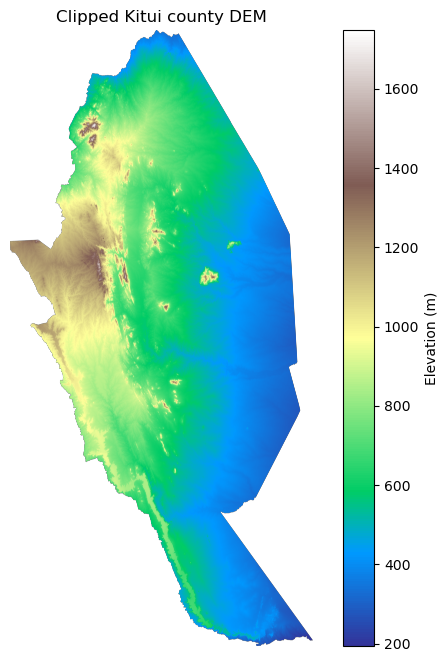

In [10]:
# Remove no data values from plotting
import numpy as np
with rasterio.open(clipped_dem_path) as src:
    dem_data = src.read(1)
    nodata = src.nodata
dem_clean = np.where(dem_data == nodata,np.nan,dem_data)

# Visualize the clipped dem
fig, ax = plt.subplots(figsize=(8,8))
dem_map = ax.imshow(dem_clean,cmap="terrain")
ax.set_title('Clipped Kitui county DEM')
ax.axis('off')
plt.colorbar(dem_map,ax=ax,label='Elevation (m)')

In [7]:
# Reproject clipped kitui county dem  back to EPSG:32737
from rasterio.warp import calculate_default_transform, reproject, Resampling

# define path
clipped_dem_path = processed / 'kitui_dem.tiff'
reprojected_dem_path = processed / 'kitui_dem_32737.tif'

with rasterio.open(clipped_dem_path) as src:
    transform, width, height = calculate_default_transform(
        src.crs,
        'EPSG:32737',
        src.width,
        src.height,
        *src.bounds


    )

    kwargs = src.meta.copy()
    kwargs.update({
        'crs': "EPSG:32737",
        'transform': transform,
        'width': width,
        'height': height
    })


    with rasterio.open(reprojected_dem_path, 'w', **kwargs) as dst:
        band = 1
        
   
        reproject(
            source=rasterio.band(src,band),
            destination=rasterio.band(dst,band),
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs='EPSG:32737',
            resampling=Resampling.bilinear

        )
print('Done')

Done


In [8]:
with rasterio.open(reprojected_dem_path) as dem:
    print('CRS',dem.crs)

CRS EPSG:32737


## Slope deriviation from DEM
The reprojected DEM is used to derive slope for Kitui county.Slope is an important terrain factor in road RWH suitability analysis because
it influences run off speed,infiltration and the construction suitability of different water harvesting stractures.

In [18]:
# Define paths
reprojected_dem_path = processed / 'kitui_dem_32737.tif'
slope_path = processed / 'kitui_slope.tif'

# Open the reprojected kitui county dem
with rasterio.open(reprojected_dem_path) as src:
    dem_data = src.read(1)
    no_data = src.nodata
    dem_meta = src.meta.copy()
    x_res, y_res = src.res

dem_clean = np.where(dem_data == no_data, np.nan,dem_data)

dy,dx = np.gradient(dem_clean, abs(y_res), abs(x_res))

slope =np.degrees(np.arctan(np.isnan(np.sqrt(dx**2 + dy**2))))
    
slope_output = np.where(np.isnan(slope),-9999,slope)

# update metadata for slope raster
dem_meta.update({
    'driver': 'GTiff',
    'dtype': 'float32',
    'nodata': -9999
    })

# Save slope raster
with rasterio.open(slope_path, 'w', **dem_meta) as dst:
    dst.write(slope_output.astype('float32'),1)
print('done')

done


## Inspecting the slope generated
After deriving slop from the reprojected DEM ,the slope raster is inspected to confirm its CRS,resolution,shape.NoData value and range
of slope values.This helps verify the slope layer is ready for reclassification and suitability analysis

In [24]:
with rasterio.open(slope_path) as src:
    slope_data = src.read(1)
    slope_nodata = src.nodata

    print('Slope CRS:', src.crs)
    print('Slope resolution:', src.res)
    print('Slope shape:', src.shape)
    print('Slope NoData:', slope_nodata)

    # clean NoData 
    slope_clan = np.where(slope_data == slope_nodata,np.nan,slope_data)
    print('Minimum slope:', np.nanmin(slope_clan))
    print('Maximm slope:', np.nanmax(slope_clan))
    print('Mean slope:', np.nanmean(slope_clan))

Slope CRS: EPSG:32737
Slope resolution: (30.74333901506157, 30.74333901506157)
Slope shape: (10844, 5357)
Slope NoData: -9999.0
Minimum slope: 0.0
Maximm slope: 45.0
Mean slope: 20.076965


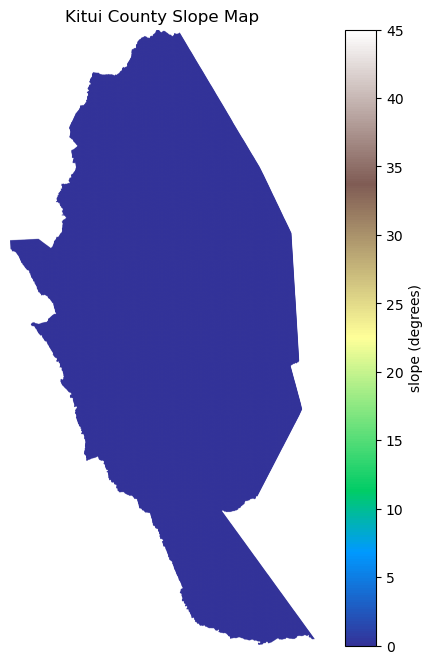

In [26]:
# visualise the slope
fig, ax = plt.subplots(figsize=(8,8))
slope_map = ax.imshow(slope_clan,cmap='terrain')
ax.set_title('Kitui County Slope Map')
ax.axis('off')
plt.colorbar(slope_map, ax=ax, label="slope (degrees)")